# Review of `log_20260408_103255.csv`

Updated static cryogenic dip-test assumptions:
- The recirculation system was **not** run for this file.
- A glass test tube held **10 mL of HFE-7200**.
- The thermocouple **`TTEST`** sat **at the bottom of the HFE**.
- Tube geometry: **15.3759 g**, **17.80 mm OD**, **1.12 mm wall**, **149 mm tall**.
- Liquid nitrogen rose to **about mid-height of the tube**, so the LN level was approximately **74.5 mm** above the bottom.
- For room-temperature reference, use the **mean of the other thermocouples** in the file.
- Vendor note from 3M: expect **crystal formation near -140 C on cooldown**, **cold crystallization near -125 C on warmup**, and a **melt temperature near -100 C on warmup**.

Goal: keep the temperature trace as context, then use only **background-subtracted** analytical plots for the three named transition points.

In [1]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from orca.cooldown import hfe_specific_heat_j_kgk
from orca.cryogenic import prepare_cryogenic_dip_study
from orca.leaks import hfe_liquid_density_kg_m3

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

tube_mass_g = 15.3759
tube_outer_d_mm = 17.80
tube_wall_mm = 1.12
tube_height_mm = 149.0
ln_depth_mm = tube_height_mm / 2.0
fill_volume_ml = 10.0
glass_cp_j_kgk = 800.0  # rough borosilicate estimate for order-of-magnitude thermal-mass comparison
named_points = [
    {
        'phase': 'cooldown',
        'temperature_c': -140.0,
        'label': 'Crystal formation',
        'color': '#b2182b',
        'marker': 'o',
        'legend_label': 'Crystal formation (-140 °C, cooldown) (from 3M)',
    },
    {
        'phase': 'warmup',
        'temperature_c': -125.0,
        'label': 'Cold crystallization',
        'color': 'C2',
        'marker': '^',
        'legend_label': 'Cold crystallization (-125 °C, warmup) (from 3M)',
    },
    {
        'phase': 'warmup',
        'temperature_c': -100.0,
        'label': 'Melt temperature',
        'color': 'C4',
        'marker': 's',
        'legend_label': 'Melt temperature (-100 °C, warmup) (from 3M)',
    },
]
phase_exclusion_windows_c = {
    'cooldown': [(-150.0, -130.0)],
    'warmup': [(-130.0, -90.0)],
}
visible_regime_spec = {
    'cooldown': {
        'n_segments': 3,
        'min_points': 30,
        'reference_key': 'ln2',
        'delta_sign': 1.0,
        'segment_colors': ['#0b4f6c', '#1f78b4', '#6baed6'],
        'regime_names': [
            'Immersion quench',
            'Bulk cooldown and freeze-out',
            'Deep-frozen tail',
        ],
        'regime_interpretations': [
            'Lower liquid column and nearby glass are dominated by direct plunge cooling into LN.',
            'The bulk HFE controls the response; viscosity rises and freeze-out likely develops within this stage.',
            'The HFE is likely mostly deep-frozen solid or glassy, so the remaining approach is conduction-limited.',
        ],
        'break_interpretations': [
            'The response stops being dominated by immersion shock and becomes bulk-HFE limited.',
            'The deep-frozen solid or glassy tail begins and the remaining approach becomes very slow.',
        ],
        'break_labels': [
            'Quench-to-bulk crossover',
            'Deep-frozen tail onset',
        ],
        'break_short_labels': ['QB', 'DT'],
        'break_colors': ['#08519c', '#2171b5'],
        'break_markers': ['o', 's'],
    },
    'warmup': {
        'n_segments': 3,
        'reference_key': 'room',
        'delta_sign': -1.0,
        'guided_break_temperature_c': -140.0,
        'tail_n_segments_after_guided_break': 2,
        'tail_min_points': 180,
        'segment_colors': ['#8c510a', '#d95f0e', '#fdb863'],
        'regime_names': [
            'Deep-frozen recovery',
            'Mobility recovery and reorganization',
            'Liquid return to ambient',
        ],
        'regime_interpretations': [
            'The deep-frozen HFE warms rapidly while molecular mobility is still strongly suppressed.',
            'Around and above -140 °C, mobility recovers enough for structural relaxation, cold crystallization, and melting-related behavior to contribute within one broad stage.',
            'By this stage the HFE behaves mostly like a liquid warming back toward room conditions.',
        ],
        'break_interpretations': [
            'Onset of mobility recovery near -140 °C in the warming solid or glassy HFE.',
            'Start of the mostly liquid ambient-return tail after the stronger cryogenic reorganization window.',
        ],
        'break_labels': [
            'Mobility-recovery onset',
            'Liquid-return onset',
        ],
        'break_short_labels': ['MR', 'LR'],
        'break_colors': ['#d94801', '#f16913'],
        'break_markers': ['^', 'D'],
    },
}


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'data' / 'raw').exists() and (candidate / 'analysis' / 'notebooks').exists():
            return candidate
    raise FileNotFoundError('Could not locate repo root from the current working directory.')


def crossing_time(frame: pd.DataFrame, threshold_c: float, *, phase: str) -> float:
    if phase == 'cooldown':
        matches = frame.loc[frame['probe_smooth_c'] <= threshold_c, 't_rel_min']
    elif phase == 'warmup':
        matches = frame.loc[frame['probe_smooth_c'] >= threshold_c, 't_rel_min']
    else:
        raise ValueError(phase)
    return float(matches.iloc[0]) if not matches.empty else float('nan')


def build_phase_summary(frame: pd.DataFrame, phase: str, *, interval_width_c: float = 5.0, min_count: int = 5) -> pd.DataFrame:
    subset = frame.loc[frame['phase'] == phase].copy()
    lower_edge_c = interval_width_c * np.floor(float(subset['probe_smooth_c'].min()) / interval_width_c)
    upper_edge_c = interval_width_c * np.ceil(float(subset['probe_smooth_c'].max()) / interval_width_c)
    bins = np.arange(lower_edge_c, upper_edge_c + interval_width_c, interval_width_c)
    subset['temperature_interval'] = pd.cut(subset['probe_smooth_c'], bins=bins, include_lowest=True)
    summary = subset.groupby('temperature_interval', observed=False).agg(
        temperature_mid_c=('probe_smooth_c', 'mean'),
        rate_c_s=('probe_rate_c_s', 'median'),
        heat_flow_w_g=('apparent_heat_flow_w_g', 'median'),
        count=('probe_smooth_c', 'size'),
    ).reset_index()
    return summary.loc[summary['count'] >= min_count].reset_index(drop=True)


def fit_background(summary: pd.DataFrame, value_column: str, exclusion_windows: list[tuple[float, float]]) -> pd.Series:
    fit_mask = np.ones(len(summary), dtype=bool)
    for low_c, high_c in exclusion_windows:
        fit_mask &= ~summary['temperature_mid_c'].between(low_c, high_c)
    fit_frame = summary.loc[fit_mask, ['temperature_mid_c', value_column, 'count']].dropna()
    degree = 3 if len(fit_frame) >= 4 else 2
    coefficients = np.polyfit(
        fit_frame['temperature_mid_c'],
        fit_frame[value_column],
        deg=degree,
        w=np.sqrt(fit_frame['count']),
    )
    return pd.Series(np.polyval(coefficients, summary['temperature_mid_c']), index=summary.index)


def nearest_interval(summary: pd.DataFrame, target_c: float) -> pd.Series:
    return summary.iloc[(summary['temperature_mid_c'] - target_c).abs().argmin()]


def feature_label(anomaly_c_s: float) -> str:
    if anomaly_c_s <= -0.015:
        return 'clear slowdown vs background'
    if anomaly_c_s <= -0.005:
        return 'mild slowdown vs background'
    if anomaly_c_s < 0.005:
        return 'near background'
    return 'faster than background'


def make_interval_cost(x: np.ndarray, y: np.ndarray):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    sx = np.concatenate([[0.0], np.cumsum(x)])
    sy = np.concatenate([[0.0], np.cumsum(y)])
    sxx = np.concatenate([[0.0], np.cumsum(x * x)])
    sxy = np.concatenate([[0.0], np.cumsum(x * y)])
    syy = np.concatenate([[0.0], np.cumsum(y * y)])

    def interval(i: int, j: int) -> tuple[float, float, float]:
        m = j - i
        sum_x = sx[j] - sx[i]
        sum_y = sy[j] - sy[i]
        sum_xx = sxx[j] - sxx[i]
        sum_xy = sxy[j] - sxy[i]
        sum_yy = syy[j] - syy[i]
        det = sum_xx * m - sum_x * sum_x
        if abs(det) < 1.0e-12:
            slope = 0.0
            intercept = sum_y / m
        else:
            slope = (sum_xy * m - sum_x * sum_y) / det
            intercept = (sum_xx * sum_y - sum_x * sum_xy) / det
        sse = max(0.0, sum_yy - slope * sum_xy - intercept * sum_y)
        return sse, slope, intercept

    return interval


def fit_exponential_segment(
    fit_time_min: np.ndarray,
    fit_temp_c: np.ndarray,
    *,
    bath_reference_c: float,
    delta_sign: float,
) -> dict:
    delta_to_bath_c = delta_sign * (fit_temp_c - bath_reference_c)
    log_delta = np.log(delta_to_bath_c)
    design = np.column_stack([fit_time_min, np.ones_like(fit_time_min)])
    coefficients, *_ = np.linalg.lstsq(design, log_delta, rcond=None)
    log_slope_per_min, log_intercept = coefficients
    fit_delta_c = np.exp(log_slope_per_min * fit_time_min + log_intercept)
    fit_y = bath_reference_c + delta_sign * fit_delta_c
    tau_min = -1.0 / log_slope_per_min if log_slope_per_min < 0.0 else np.inf
    return {
        'fit_x': fit_time_min,
        'fit_y': fit_y,
        'tau_min': float(tau_min),
        'bath_reference_c': float(bath_reference_c),
    }


def fit_piecewise_exponential_regimes(
    frame: pd.DataFrame,
    *,
    phase: str,
    bath_reference_c: float,
    delta_sign: float,
    n_segments: int,
    min_points: int,
    segment_colors: list[str],
    regime_names: list[str],
    regime_interpretations: list[str],
    break_interpretations: list[str],
    break_labels: list[str],
    break_short_labels: list[str],
    break_colors: list[str],
    break_markers: list[str],
) -> dict:
    subset = frame.loc[frame['phase'] == phase].reset_index(drop=True)
    all_time_min = subset['t_rel_min'].to_numpy(dtype=float)
    all_temp_c = subset['probe_smooth_c'].to_numpy(dtype=float)
    delta_to_bath_c = delta_sign * (all_temp_c - bath_reference_c)
    keep_mask = delta_to_bath_c > 0.5

    fit_time_min = all_time_min[keep_mask]
    fit_temp_c = all_temp_c[keep_mask]
    log_delta = np.log(delta_to_bath_c[keep_mask])
    interval_cost = make_interval_cost(fit_time_min, log_delta)
    n = len(fit_time_min)

    dp = np.full((n_segments + 1, n + 1), np.inf)
    prev = np.full((n_segments + 1, n + 1), -1, dtype=int)
    dp[0, 0] = 0.0

    for k in range(1, n_segments + 1):
        start_j = k * min_points
        end_j = n - (n_segments - k) * min_points
        for j in range(start_j, end_j + 1):
            best_value = np.inf
            best_i = -1
            i_min = (k - 1) * min_points
            i_max = j - min_points
            for i in range(i_min, i_max + 1):
                sse, _, _ = interval_cost(i, j)
                value = dp[k - 1, i] + sse
                if value < best_value:
                    best_value = value
                    best_i = i
            dp[k, j] = best_value
            prev[k, j] = best_i

    bounds = [n]
    j = n
    for k in range(n_segments, 0, -1):
        i = prev[k, j]
        bounds.append(i)
        j = i
    bounds = sorted(bounds)

    segments = []
    for regime_number, (start, end) in enumerate(zip(bounds[:-1], bounds[1:]), start=1):
        _, log_slope_per_min, log_intercept = interval_cost(start, end)
        fit_x = fit_time_min[start:end]
        fit_delta_c = np.exp(log_slope_per_min * fit_x + log_intercept)
        fit_y = bath_reference_c + delta_sign * fit_delta_c
        tau_min = -1.0 / log_slope_per_min if log_slope_per_min < 0.0 else np.inf
        segments.append(
            {
                'phase': phase,
                'regime_number': regime_number,
                'label': regime_names[regime_number - 1],
                'name': regime_names[regime_number - 1],
                'start_time_min': float(fit_time_min[start]),
                'end_time_min': float(fit_time_min[end - 1]),
                'start_temp_c': float(fit_temp_c[start]),
                'end_temp_c': float(fit_temp_c[end - 1]),
                'tau_min': float(tau_min),
                'bath_reference_c': float(bath_reference_c),
                'fit_x': fit_x,
                'fit_y': fit_y,
                'color': segment_colors[regime_number - 1],
                'interpretation': regime_interpretations[regime_number - 1],
            }
        )

    breakpoints = []
    for break_number, boundary in enumerate(bounds[1:-1], start=1):
        breakpoints.append(
            {
                'phase': phase,
                'break_number': break_number,
                'short_label': break_short_labels[break_number - 1],
                'label': break_labels[break_number - 1],
                'legend_label': break_labels[break_number - 1],
                'time_min': float(fit_time_min[boundary]),
                'temperature_c': float(fit_temp_c[boundary]),
                'color': break_colors[break_number - 1],
                'marker': break_markers[break_number - 1],
                'interpretation': break_interpretations[break_number - 1],
                'before_regime': break_number,
                'after_regime': break_number + 1,
            }
        )

    return {
        'phase': phase,
        'segments': segments,
        'breakpoints': breakpoints,
        'bounds': bounds,
        'total_sse': float(dp[n_segments, n]),
    }


repo_root = find_repo_root()
log_path = repo_root / 'data' / 'raw' / 'log_20260408_103255.csv'

study = prepare_cryogenic_dip_study(log_path)
data = study.data.copy()

inner_d_mm = tube_outer_d_mm - 2.0 * tube_wall_mm
inner_r_mm = inner_d_mm / 2.0
fill_height_mm = fill_volume_ml * 1000.0 / (math.pi * inner_r_mm**2)
ln_above_fill_mm = ln_depth_mm - fill_height_mm

room_reference_c = float(data['reference_mean_c'].median())
regime_reference_c = {
    'ln2': float(study.ln2_reference_c),
    'room': room_reference_c,
}

hfe_density_kg_m3 = hfe_liquid_density_kg_m3(room_reference_c)
hfe_mass_kg = fill_volume_ml * 1.0e-6 * hfe_density_kg_m3
hfe_mass_g = 1000.0 * hfe_mass_kg
hfe_cp_room_j_kgk = hfe_specific_heat_j_kgk(room_reference_c + 273.15)
hfe_capacity_room_j_k = hfe_mass_kg * hfe_cp_room_j_kgk
glass_capacity_j_k = (tube_mass_g / 1000.0) * glass_cp_j_kgk

data['hfe_cp_j_kgk'] = data['probe_smooth_c'].apply(lambda temp_c: hfe_specific_heat_j_kgk(float(temp_c) + 273.15))
data['apparent_capacity_j_k'] = glass_capacity_j_k + hfe_mass_kg * data['hfe_cp_j_kgk']
data['apparent_heat_flow_w_g'] = (data['apparent_capacity_j_k'] * data['probe_rate_c_s']) / hfe_mass_g

cooldown = data.loc[data['phase'] == 'cooldown'].copy()
warmup = data.loc[data['phase'] == 'warmup'].copy()

cooldown_summary = build_phase_summary(data, 'cooldown')
warmup_summary = build_phase_summary(data, 'warmup')

for phase_name, summary in [('cooldown', cooldown_summary), ('warmup', warmup_summary)]:
    summary['rate_background_c_s'] = fit_background(
        summary,
        'rate_c_s',
        phase_exclusion_windows_c[phase_name],
    )
    summary['heat_background_w_g'] = fit_background(
        summary,
        'heat_flow_w_g',
        phase_exclusion_windows_c[phase_name],
    )
    summary['rate_delta_c_s'] = summary['rate_c_s'] - summary['rate_background_c_s']
    summary['heat_delta_w_g'] = summary['heat_flow_w_g'] - summary['heat_background_w_g']
    if phase_name == 'cooldown':
        summary['rate_anomaly_c_s'] = -summary['rate_delta_c_s']
        summary['heat_anomaly_w_g'] = -summary['heat_delta_w_g']
    else:
        summary['rate_anomaly_c_s'] = summary['rate_delta_c_s']
        summary['heat_anomaly_w_g'] = summary['heat_delta_w_g']

plot_points = []
for point in named_points:
    phase_name = point['phase']
    frame = cooldown if phase_name == 'cooldown' else warmup
    summary = cooldown_summary if phase_name == 'cooldown' else warmup_summary
    row = nearest_interval(summary, point['temperature_c'])
    plot_points.append(
        {
            **point,
            'nearest_temperature_c': float(row['temperature_mid_c']),
            'crossing_time_min': crossing_time(frame, point['temperature_c'], phase=phase_name),
            'actual_rate_c_s': float(row['rate_c_s']),
            'background_rate_c_s': float(row['rate_background_c_s']),
            'actual_heat_flow_w_g': float(row['heat_flow_w_g']),
            'background_heat_flow_w_g': float(row['heat_background_w_g']),
            'rate_anomaly_c_s': float(row['rate_anomaly_c_s']),
            'heat_anomaly_w_g': float(row['heat_anomaly_w_g']),
        }
    )

phase_point_map = {
    'cooldown': [point for point in plot_points if point['phase'] == 'cooldown'],
    'warmup': [point for point in plot_points if point['phase'] == 'warmup'],
}

target_rows = []
for point in plot_points:
    target_rows.append(
        {
            'Phase': point['phase'],
            'Transition': point['label'],
            'Nominal temperature [°C]': point['temperature_c'],
            'Nearest interval mean [°C]': point['nearest_temperature_c'],
            'Crossing time [min]': point['crossing_time_min'],
            'Background-subtracted rate [°C/s]': point['rate_anomaly_c_s'],
            'Background-subtracted heat flow [W/g]': point['heat_anomaly_w_g'],
            'Readout': feature_label(point['rate_anomaly_c_s']),
        }
    )
target_summary = pd.DataFrame(target_rows).reset_index(drop=True)

regime_models = {}

cooldown_spec = visible_regime_spec['cooldown']
regime_models['cooldown'] = fit_piecewise_exponential_regimes(
    data,
    phase='cooldown',
    bath_reference_c=regime_reference_c[cooldown_spec['reference_key']],
    delta_sign=cooldown_spec['delta_sign'],
    n_segments=cooldown_spec['n_segments'],
    min_points=cooldown_spec['min_points'],
    segment_colors=cooldown_spec['segment_colors'],
    regime_names=cooldown_spec['regime_names'],
    regime_interpretations=cooldown_spec['regime_interpretations'],
    break_interpretations=cooldown_spec['break_interpretations'],
    break_labels=cooldown_spec['break_labels'],
    break_short_labels=cooldown_spec['break_short_labels'],
    break_colors=cooldown_spec['break_colors'],
    break_markers=cooldown_spec['break_markers'],
)

warmup_spec = visible_regime_spec['warmup']
warmup_subset = data.loc[data['phase'] == 'warmup'].reset_index(drop=True)
warmup_time_all = warmup_subset['t_rel_min'].to_numpy(dtype=float)
warmup_temp_all = warmup_subset['probe_smooth_c'].to_numpy(dtype=float)
warmup_delta_to_room_c = warmup_spec['delta_sign'] * (warmup_temp_all - regime_reference_c[warmup_spec['reference_key']])
warmup_keep_mask = warmup_delta_to_room_c > 0.5
warmup_fit_time_min = warmup_time_all[warmup_keep_mask]
warmup_fit_temp_c = warmup_temp_all[warmup_keep_mask]

base_warmup_model = fit_piecewise_exponential_regimes(
    data,
    phase='warmup',
    bath_reference_c=regime_reference_c[warmup_spec['reference_key']],
    delta_sign=warmup_spec['delta_sign'],
    n_segments=warmup_spec['tail_n_segments_after_guided_break'],
    min_points=warmup_spec['tail_min_points'],
    segment_colors=warmup_spec['segment_colors'][-warmup_spec['tail_n_segments_after_guided_break']:],
    regime_names=warmup_spec['regime_names'][-warmup_spec['tail_n_segments_after_guided_break']:],
    regime_interpretations=warmup_spec['regime_interpretations'][-warmup_spec['tail_n_segments_after_guided_break']:],
    break_interpretations=warmup_spec['break_interpretations'][-1:],
    break_labels=warmup_spec['break_labels'][-1:],
    break_short_labels=warmup_spec['break_short_labels'][-1:],
    break_colors=warmup_spec['break_colors'][-1:],
    break_markers=warmup_spec['break_markers'][-1:],
)

warmup_break_1_index = int(np.argmax(warmup_fit_temp_c >= warmup_spec['guided_break_temperature_c']))
warmup_break_2_time_min = base_warmup_model['breakpoints'][0]['time_min']
warmup_break_2_index = int(np.argmax(warmup_fit_time_min >= warmup_break_2_time_min))
warmup_bounds = [0, warmup_break_1_index, warmup_break_2_index, len(warmup_fit_time_min)]

warmup_segments = []
for regime_number, (start, end) in enumerate(zip(warmup_bounds[:-1], warmup_bounds[1:]), start=1):
    segment_fit = fit_exponential_segment(
        warmup_fit_time_min[start:end],
        warmup_fit_temp_c[start:end],
        bath_reference_c=regime_reference_c[warmup_spec['reference_key']],
        delta_sign=warmup_spec['delta_sign'],
    )
    warmup_segments.append(
        {
            'phase': 'warmup',
            'regime_number': regime_number,
            'label': warmup_spec['regime_names'][regime_number - 1],
            'name': warmup_spec['regime_names'][regime_number - 1],
            'start_time_min': float(warmup_fit_time_min[start]),
            'end_time_min': float(warmup_fit_time_min[end - 1]),
            'start_temp_c': float(warmup_fit_temp_c[start]),
            'end_temp_c': float(warmup_fit_temp_c[end - 1]),
            'tau_min': segment_fit['tau_min'],
            'bath_reference_c': segment_fit['bath_reference_c'],
            'fit_x': segment_fit['fit_x'],
            'fit_y': segment_fit['fit_y'],
            'color': warmup_spec['segment_colors'][regime_number - 1],
            'interpretation': warmup_spec['regime_interpretations'][regime_number - 1],
        }
    )

warmup_breakpoints = []
for break_number, boundary in enumerate(warmup_bounds[1:-1], start=1):
    warmup_breakpoints.append(
        {
            'phase': 'warmup',
            'break_number': break_number,
            'short_label': warmup_spec['break_short_labels'][break_number - 1],
            'label': warmup_spec['break_labels'][break_number - 1],
            'legend_label': warmup_spec['break_labels'][break_number - 1],
            'time_min': float(warmup_fit_time_min[boundary]),
            'temperature_c': float(warmup_fit_temp_c[boundary]),
            'color': warmup_spec['break_colors'][break_number - 1],
            'marker': warmup_spec['break_markers'][break_number - 1],
            'interpretation': warmup_spec['break_interpretations'][break_number - 1],
            'before_regime': break_number,
            'after_regime': break_number + 1,
        }
    )

regime_models['warmup'] = {
    'phase': 'warmup',
    'segments': warmup_segments,
    'breakpoints': warmup_breakpoints,
    'bounds': warmup_bounds,
    'total_sse': float(sum(np.sum((segment['fit_y'] - warmup_fit_temp_c[start:end]) ** 2) for segment, (start, end) in zip(warmup_segments, zip(warmup_bounds[:-1], warmup_bounds[1:])))),
}

regime_rows = []
regime_break_rows = []
for phase_name in ['cooldown', 'warmup']:
    model = regime_models[phase_name]
    for segment in model['segments']:
        regime_rows.append(
            {
                'Phase': phase_name,
                'Regime': segment['regime_number'],
                'Regime name': segment['name'],
                'Bath reference [°C]': segment['bath_reference_c'],
                'Start time [min]': segment['start_time_min'],
                'End time [min]': segment['end_time_min'],
                'Start temperature [°C]': segment['start_temp_c'],
                'End temperature [°C]': segment['end_temp_c'],
                'Tau [min]': segment['tau_min'],
                'Interpretation': segment['interpretation'],
            }
        )
    for breakpoint in model['breakpoints']:
        regime_break_rows.append(
            {
                'Point': breakpoint['short_label'],
                'Point name': breakpoint['label'],
                'Phase': phase_name,
                'Time [min]': breakpoint['time_min'],
                'Temperature [°C]': breakpoint['temperature_c'],
                'Between regimes': f"{breakpoint['before_regime']} -> {breakpoint['after_regime']}",
                'Interpretation': breakpoint['interpretation'],
            }
        )

regime_summary = pd.DataFrame(regime_rows)
regime_breakpoints = pd.DataFrame(regime_break_rows)
regime_plot_points = regime_models['cooldown']['breakpoints'] + regime_models['warmup']['breakpoints']

x_min_c = float(np.floor(min(cooldown_summary['temperature_mid_c'].min(), warmup_summary['temperature_mid_c'].min()) / 5.0) * 5.0)
x_max_c = float(np.ceil(max(cooldown_summary['temperature_mid_c'].max(), warmup_summary['temperature_mid_c'].max()) / 5.0) * 5.0)
global_x_limits = (x_min_c, x_max_c)

overview = pd.DataFrame(
    [
        ('Room reference', f'Mean of other TCs = {room_reference_c:.2f} °C'),
        ('Tube inner diameter', f'{inner_d_mm:.2f} mm'),
        ('HFE fill height', f'{fill_height_mm:.1f} mm'),
        ('LN depth', f'{ln_depth_mm:.1f} mm'),
        ('LN above liquid top', f'{ln_above_fill_mm:.1f} mm'),
        ('Estimated HFE mass at room T', f'{hfe_mass_g:.2f} g'),
        ('HFE sensible capacity at room T', f'{hfe_capacity_room_j_k:.2f} J/K'),
        ('Glass sensible capacity estimate', f'{glass_capacity_j_k:.2f} J/K'),
        ('Smoothed minimum', f'{study.turnaround_time_min:.2f} min at {study.turnaround_temp_c:.1f} °C'),
    ],
    columns=['Metric', 'Value'],
)

overview

,Metric,Value
0,Room reference,Mean of other TCs = 20.85 °C
1,Tube inner diameter,15.56 mm
2,HFE fill height,52.6 mm
3,LN depth,74.5 mm
4,LN above liquid top,21.9 mm
5,Estimated HFE mass at room T,14.33 g
6,HFE sensible capacity at room T,17.40 J/K
7,Glass sensible capacity estimate,12.30 J/K
8,Smoothed minimum,22.11 min at -172.6 °C


## Background Definition

The **temperature-vs-time plots below are raw context plus model overlays**. The derivative-style plots now show the **measured signed values only**.

Background definition for the vendor-comparison table:
- The smoothed `TTEST` trace is grouped into **5 °C temperature intervals**.
- For each interval and each phase, the tabulated value is the **median** of the samples in that interval.
- A **weighted cubic polynomial** is fit as the smooth background, using the interval sample counts as weights.
- The fit excludes the expected transition window for that phase so the background does not absorb the feature we want to inspect.
- Cooldown background exclusion: **-150 °C to -130 °C** around crystal formation.
- Warmup background exclusion: **-130 °C to -90 °C** so both cold crystallization and melt-temperature features stay out of the baseline fit.

Plot conventions:
- The rate plots show the measured **temperature derivative `dT/dt`** directly.
- Therefore, `dT/dt` is **negative on cooldown** and **positive on warmup**, which is the physically correct sign convention.
- The rate and heat-flow plots no longer show the smooth background; they show only the measured values plus the vendor reference points.
- The table above still reports a **phase-oriented background-subtracted anomaly** so that a **slowdown** is negative in both cooldown and warmup.
- The regime-fit plot uses a first-order thermal model, `T(t) = T_bath + A exp(-t / tau)`, because a lumped thermal mass approaching a nearly constant bath should be exponential rather than linear in `T(t)`.
- Cooldown uses **LN2 at -196 °C** as the bath reference. Warmup uses the **mean of the other thermocouples** as the room-side reference.

In [2]:
target_summary.style.format(
    {
        'Nominal temperature [°C]': '{:.0f}',
        'Nearest interval mean [°C]': '{:.1f}',
        'Crossing time [min]': '{:.2f}',
        'Background-subtracted rate [°C/s]': '{:.4f}',
        'Background-subtracted heat flow [W/g]': '{:.4f}',
    }
)

,Phase,Transition,Nominal temperature [°C],Nearest interval mean [°C],Crossing time [min],Background-subtracted rate [°C/s],Background-subtracted heat flow [W/g],Readout
0,cooldown,Crystal formation,-140,-137.6,15.19,-0.0244,-0.0437,clear slowdown vs background
1,warmup,Cold crystallization,-125,-127.5,26.43,-0.0192,-0.0341,clear slowdown vs background
2,warmup,Melt temperature,-100,-102.5,30.60,-0.0281,-0.0514,clear slowdown vs background


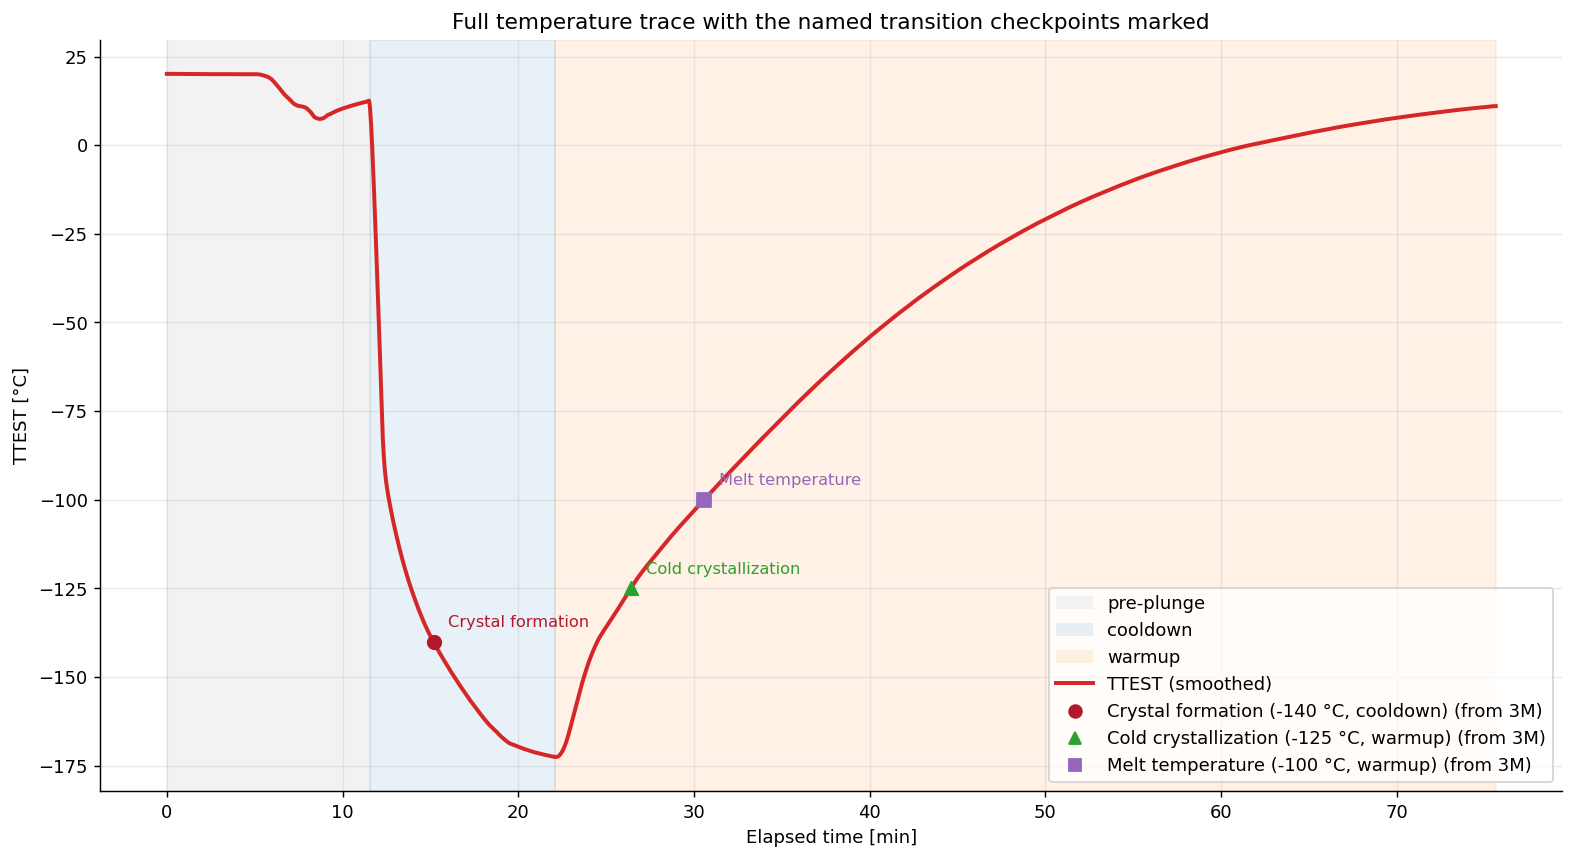

In [3]:
fig, ax = plt.subplots(figsize=(12, 6.5), constrained_layout=True)

ax.axvspan(data['t_rel_min'].min(), study.plunge_time_min, color='0.95')
ax.axvspan(study.plunge_time_min, study.turnaround_time_min, color='C0', alpha=0.10)
ax.axvspan(study.turnaround_time_min, data['t_rel_min'].max(), color='C1', alpha=0.10)
ax.plot(data['t_rel_min'], data['probe_smooth_c'], color='C3', lw=2.2)

for point in plot_points:
    t_cross = point['crossing_time_min']
    if np.isfinite(t_cross):
        ax.scatter(
            t_cross,
            point['temperature_c'],
            color=point['color'],
            marker=point['marker'],
            s=55,
            zorder=3,
        )
        ax.annotate(
            point['label'],
            xy=(t_cross, point['temperature_c']),
            xytext=(8, 8),
            textcoords='offset points',
            fontsize=9,
            color=point['color'],
        )

ax.set_xlabel('Elapsed time [min]')
ax.set_ylabel('TTEST [°C]')
ax.set_title('Full temperature trace with the named transition checkpoints marked')

legend_handles = [
    Patch(facecolor='0.95', edgecolor='none', label='pre-plunge'),
    Patch(facecolor='C0', edgecolor='none', alpha=0.10, label='cooldown'),
    Patch(facecolor='C1', edgecolor='none', alpha=0.10, label='warmup'),
    Line2D([], [], color='C3', lw=2.2, label='TTEST (smoothed)'),
]
legend_handles.extend(
    [
        Line2D(
            [],
            [],
            marker=point['marker'],
            color=point['color'],
            linestyle='',
            markersize=7,
            label=point['legend_label'],
        )
        for point in plot_points
    ]
)
ax.legend(handles=legend_handles, loc='best')

plt.show()

## Data-derived Regimes

A straight line in `TTEST(t)` is not the right first-order thermal model here. If the sample behaves approximately like a lumped thermal mass with an effective heat-transfer coefficient, then

`dT/dt = -(T - T_bath) / tau`

and `T(t)` should approach the bath temperature **exponentially**, not linearly.

So the next plot uses **piecewise exponential fits**:
- **3 cooldown segments** toward the LN2 bath,
- **3 warmup segments** toward the room-side reference.

The regime names below are meant to describe the most plausible **effective thermal state** of the HFE:
- an initial **immersion quench**,
- a **bulk cooldown and freeze-out** stage,
- a **deep-frozen tail** on cooldown,
- then **deep-frozen recovery**, **mobility recovery and reorganization**, and finally **liquid return to ambient** on warmup.

These are still **coarse effective thermal regimes**. A change in `tau` means the effective transport or effective heat capacity changed; it does **not** by itself prove a sharp thermodynamic phase boundary.

In [4]:
display(
    regime_summary.style.format(
        {
            'Bath reference [°C]': '{:.1f}',
            'Start time [min]': '{:.2f}',
            'End time [min]': '{:.2f}',
            'Start temperature [°C]': '{:.1f}',
            'End temperature [°C]': '{:.1f}',
            'Tau [min]': '{:.2f}',
        }
    )
)

display(
    regime_breakpoints.style.format(
        {
            'Time [min]': '{:.2f}',
            'Temperature [°C]': '{:.1f}',
        }
    )
)

,Phase,Regime,Regime name,Bath reference [°C],Start time [min],End time [min],Start temperature [°C],End temperature [°C],Tau [min],Interpretation
0,cooldown,1,Immersion quench,-196.0,11.54,12.62,11.9,-99.5,1.23,Lower liquid column and nearby glass are dominated by direct plunge cooling into LN.
1,cooldown,2,Bulk cooldown and freeze-out,-196.0,12.65,19.21,-100.3,-167.6,5.60,The bulk HFE controls the response; viscosity rises and freeze-out likely develops within this stage.
2,cooldown,3,Deep-frozen tail,-196.0,19.24,22.08,-167.7,-172.5,16.03,"The HFE is likely mostly deep-frozen solid or glassy, so the remaining approach is conduction-limited."
3,warmup,1,Deep-frozen recovery,20.8,22.11,24.50,-172.6,-140.1,11.39,The deep-frozen HFE warms rapidly while molecular mobility is still strongly suppressed.
4,warmup,2,Mobility recovery and reorganization,20.8,24.53,35.88,-139.8,-72.7,21.55,"Around and above -140 °C, mobility recovers enough for structural relaxation, cold crystallization, and melting-related behavior to contribute within one broad stage."
5,warmup,3,Liquid return to ambient,20.8,35.91,75.63,-72.6,11.0,17.25,By this stage the HFE behaves mostly like a liquid warming back toward room conditions.


,Point,Point name,Phase,Time [min],Temperature [°C],Between regimes,Interpretation
0,QB,Quench-to-bulk crossover,cooldown,12.65,-100.3,1 -> 2,The response stops being dominated by immersion shock and becomes bulk-HFE limited.
1,DT,Deep-frozen tail onset,cooldown,19.24,-167.7,2 -> 3,The deep-frozen solid or glassy tail begins and the remaining approach becomes very slow.
2,MR,Mobility-recovery onset,warmup,24.53,-139.8,1 -> 2,Onset of mobility recovery near -140 °C in the warming solid or glassy HFE.
3,LR,Liquid-return onset,warmup,35.91,-72.6,2 -> 3,Start of the mostly liquid ambient-return tail after the stronger cryogenic reorganization window.


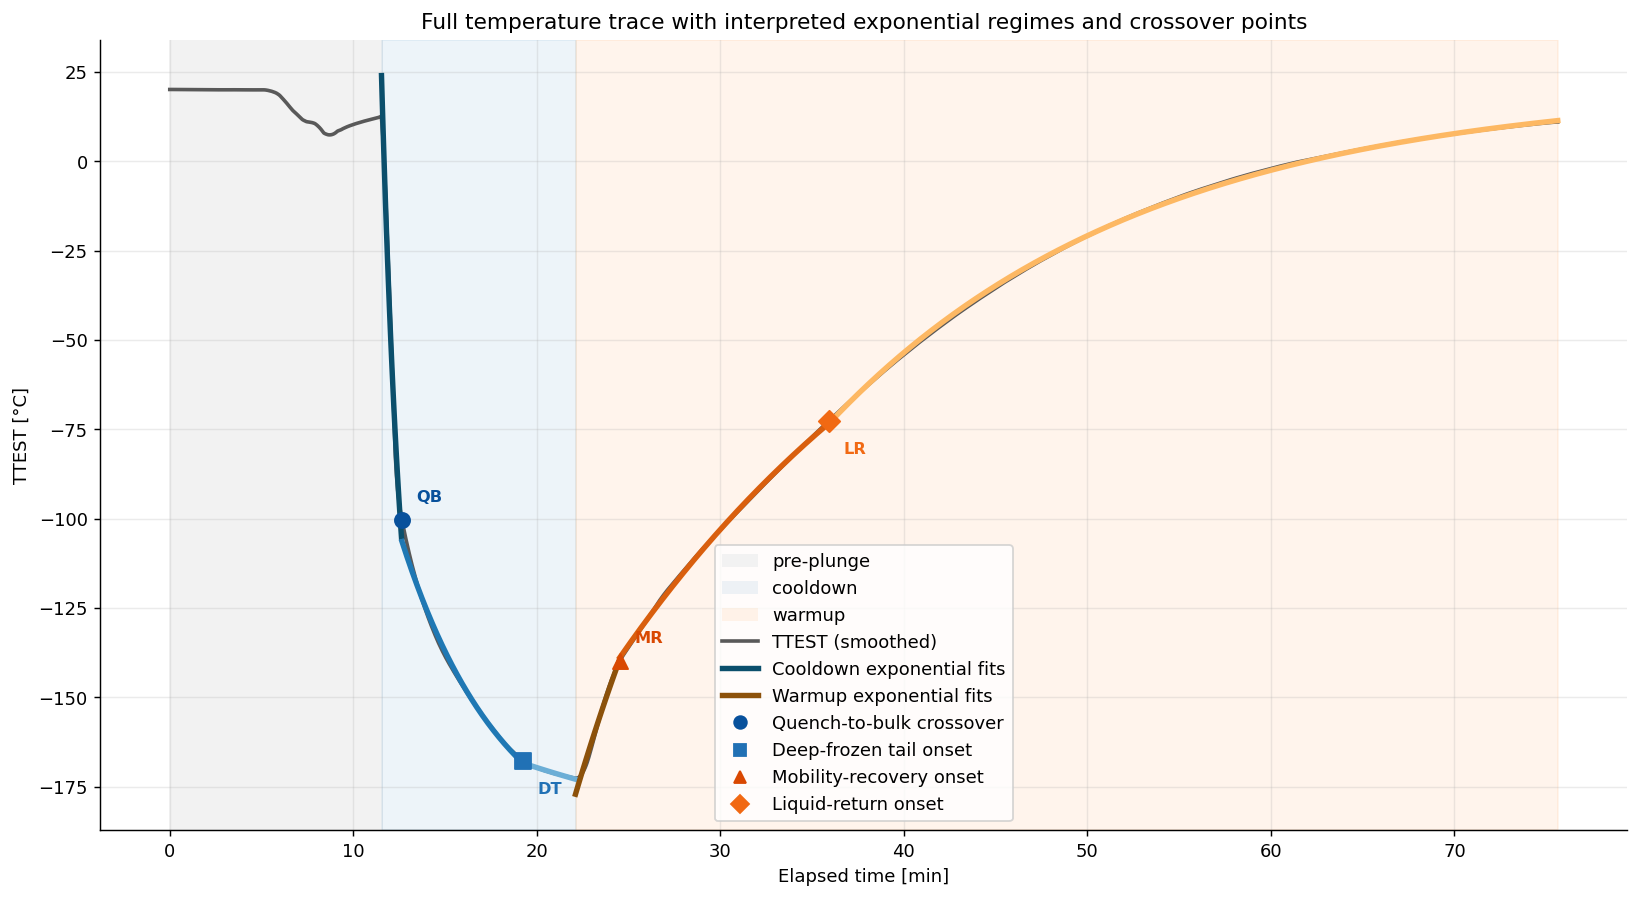

In [5]:
fig, ax = plt.subplots(figsize=(12.5, 6.8), constrained_layout=True)

ax.axvspan(data['t_rel_min'].min(), study.plunge_time_min, color='0.95')
ax.axvspan(study.plunge_time_min, study.turnaround_time_min, color='C0', alpha=0.08)
ax.axvspan(study.turnaround_time_min, data['t_rel_min'].max(), color='C1', alpha=0.08)
ax.plot(data['t_rel_min'], data['probe_smooth_c'], color='0.35', lw=2.0)

legend_handles = [
    Patch(facecolor='0.95', edgecolor='none', label='pre-plunge'),
    Patch(facecolor='C0', edgecolor='none', alpha=0.08, label='cooldown'),
    Patch(facecolor='C1', edgecolor='none', alpha=0.08, label='warmup'),
    Line2D([], [], color='0.35', lw=2.0, label='TTEST (smoothed)'),
]

for phase_name, phase_label in [('cooldown', 'Cooldown exponential fits'), ('warmup', 'Warmup exponential fits')]:
    model = regime_models[phase_name]
    for segment in model['segments']:
        ax.plot(segment['fit_x'], segment['fit_y'], color=segment['color'], lw=3.0)
    legend_handles.append(
        Line2D([], [], color=model['segments'][0]['color'], lw=3.0, label=phase_label)
    )

annotation_offsets = {
    'QB': (8, 10),
    'DT': (8, -18),
    'MR': (8, 10),
    'LR': (8, -18),
}
for point in regime_plot_points:
    ax.scatter(
        point['time_min'],
        point['temperature_c'],
        color=point['color'],
        marker=point['marker'],
        s=70,
        zorder=4,
    )
    dx, dy = annotation_offsets[point['short_label']]
    ax.annotate(
        point['short_label'],
        xy=(point['time_min'], point['temperature_c']),
        xytext=(dx, dy),
        textcoords='offset points',
        fontsize=9,
        color=point['color'],
        weight='bold',
    )
    legend_handles.append(
        Line2D(
            [],
            [],
            marker=point['marker'],
            color=point['color'],
            linestyle='',
            markersize=7,
            label=point['legend_label'],
        )
    )

ax.set_xlabel('Elapsed time [min]')
ax.set_ylabel('TTEST [°C]')
ax.set_title('Full temperature trace with interpreted exponential regimes and crossover points')
ax.legend(handles=legend_handles, loc='best')

plt.show()

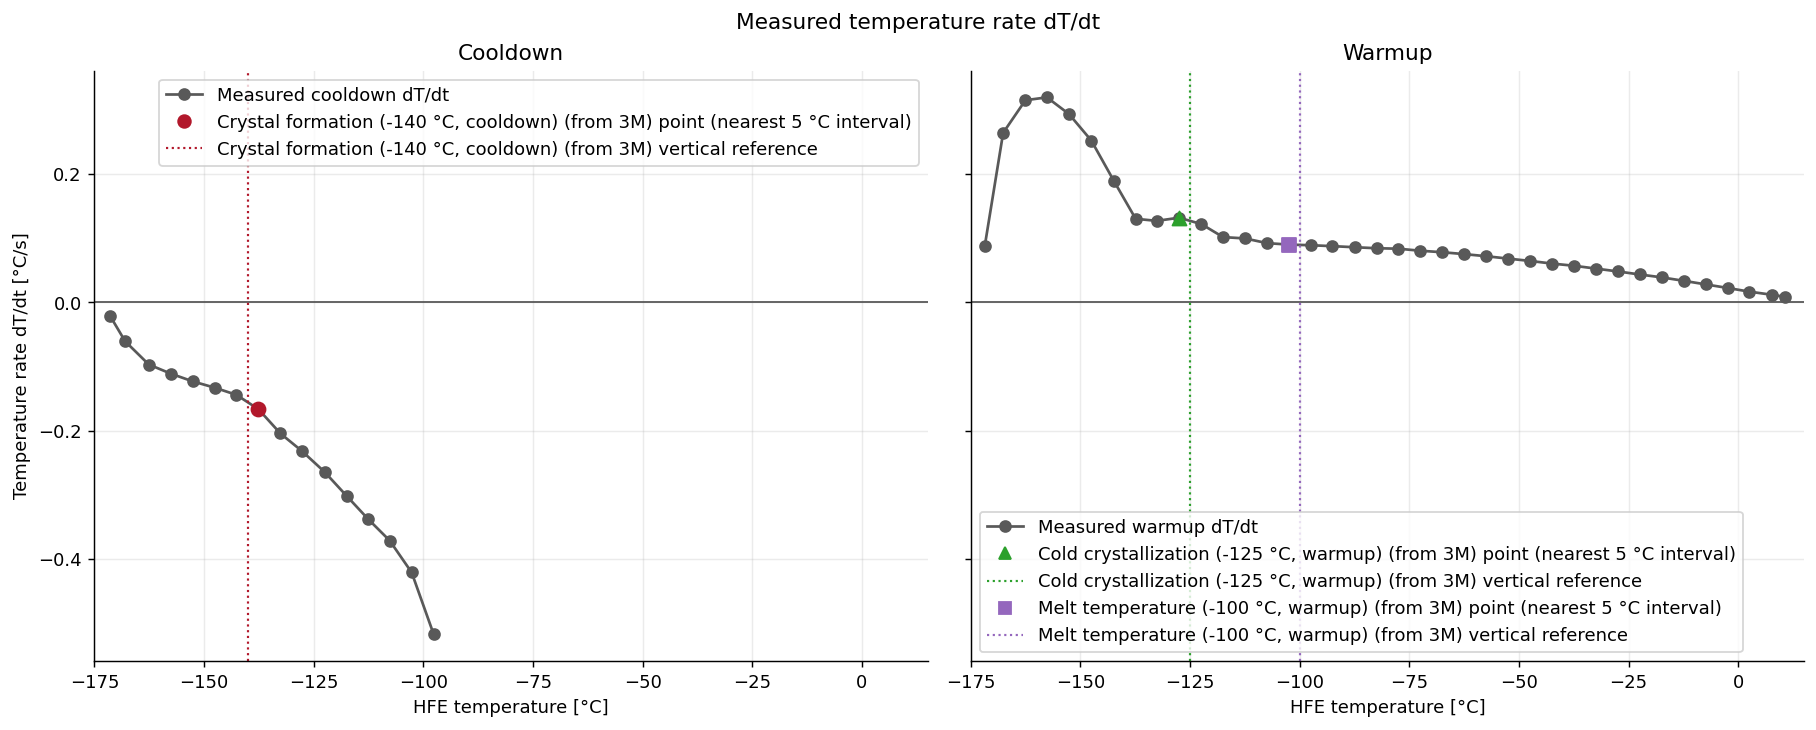

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.5), sharey=True, sharex=True, constrained_layout=True)

phase_series = {
    'cooldown': {
        'summary': cooldown_summary,
        'title': 'Cooldown',
        'color': '0.35',
        'label': 'Measured cooldown dT/dt',
    },
    'warmup': {
        'summary': warmup_summary,
        'title': 'Warmup',
        'color': '0.35',
        'label': 'Measured warmup dT/dt',
    },
}

for ax, phase_name in zip(axes, ['cooldown', 'warmup']):
    series = phase_series[phase_name]
    summary = series['summary']
    ax.plot(
        summary['temperature_mid_c'],
        summary['rate_c_s'],
        marker='o',
        color=series['color'],
    )
    ax.axhline(0.0, color='0.35', lw=1)

    legend_handles = [
        Line2D([], [], color=series['color'], marker='o', label=series['label']),
    ]

    for point in phase_point_map[phase_name]:
        ax.scatter(
            point['nearest_temperature_c'],
            point['actual_rate_c_s'],
            color=point['color'],
            marker=point['marker'],
            s=60,
            zorder=3,
        )
        ax.axvline(point['temperature_c'], color=point['color'], ls=':', lw=1.2)
        legend_handles.append(
            Line2D(
                [],
                [],
                color=point['color'],
                marker=point['marker'],
                linestyle='',
                markersize=7,
                label=f"{point['legend_label']} point (nearest 5 °C interval)",
            )
        )
        legend_handles.append(
            Line2D(
                [],
                [],
                color=point['color'],
                linestyle=':',
                lw=1.2,
                label=f"{point['legend_label']} vertical reference",
            )
        )

    ax.set_xlim(*global_x_limits)
    ax.set_xlabel('HFE temperature [°C]')
    ax.set_title(series['title'])
    ax.legend(handles=legend_handles, loc='best')

axes[0].set_ylabel('Temperature rate dT/dt [°C/s]')
fig.suptitle('Measured temperature rate dT/dt')

plt.show()

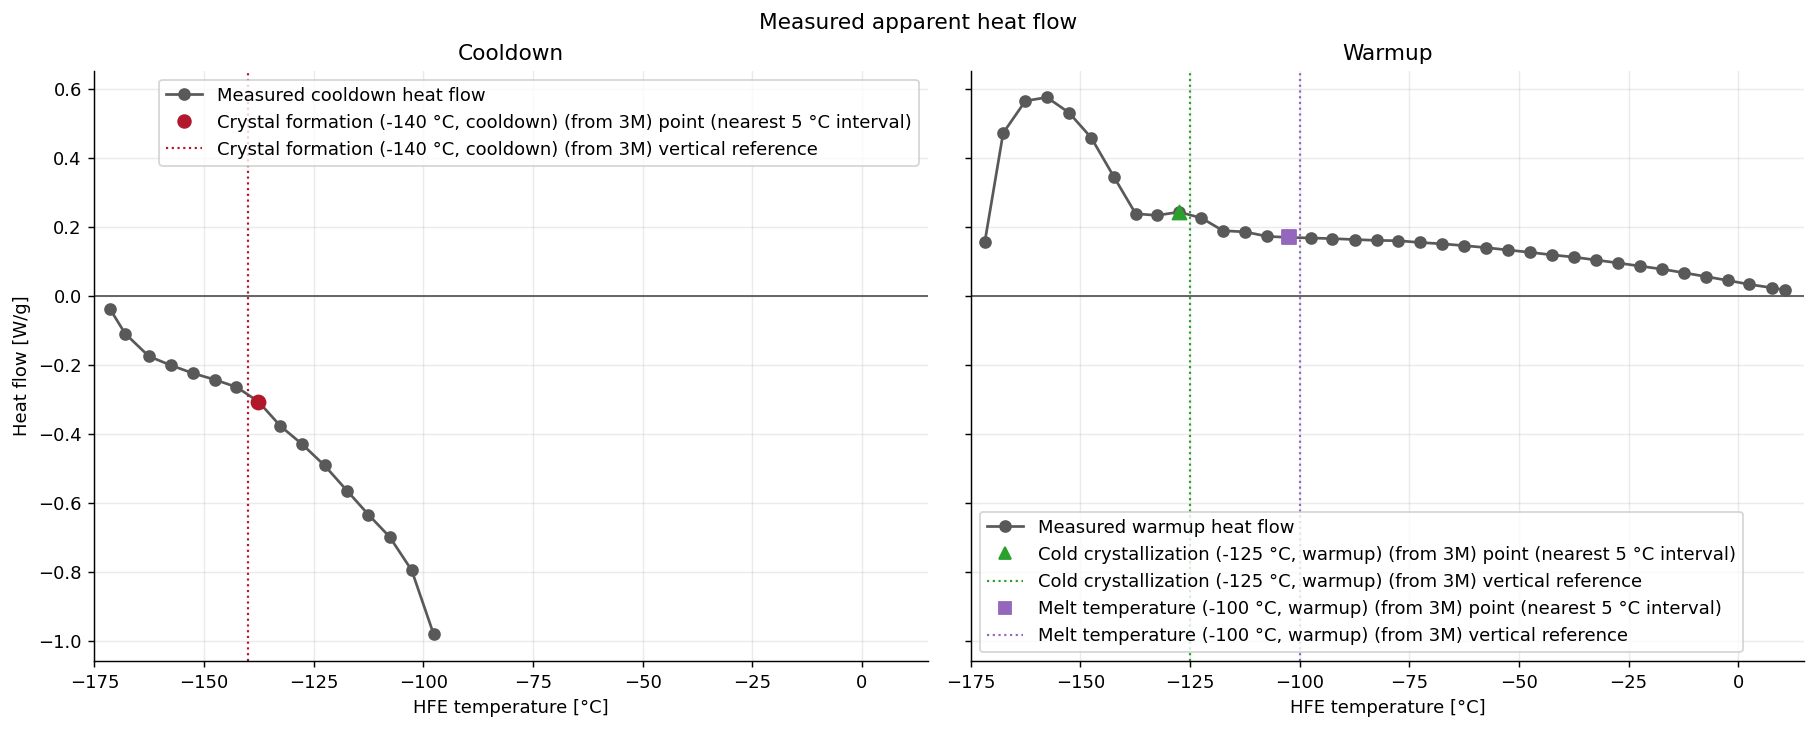

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.5), sharey=True, sharex=True, constrained_layout=True)

phase_series = {
    'cooldown': {
        'summary': cooldown_summary,
        'title': 'Cooldown',
        'color': '0.35',
        'label': 'Measured cooldown heat flow',
    },
    'warmup': {
        'summary': warmup_summary,
        'title': 'Warmup',
        'color': '0.35',
        'label': 'Measured warmup heat flow',
    },
}

for ax, phase_name in zip(axes, ['cooldown', 'warmup']):
    series = phase_series[phase_name]
    summary = series['summary']
    ax.plot(
        summary['temperature_mid_c'],
        summary['heat_flow_w_g'],
        marker='o',
        color=series['color'],
    )
    ax.axhline(0.0, color='0.35', lw=1)

    legend_handles = [
        Line2D([], [], color=series['color'], marker='o', label=series['label']),
    ]

    for point in phase_point_map[phase_name]:
        ax.scatter(
            point['nearest_temperature_c'],
            point['actual_heat_flow_w_g'],
            color=point['color'],
            marker=point['marker'],
            s=60,
            zorder=3,
        )
        ax.axvline(point['temperature_c'], color=point['color'], ls=':', lw=1.2)
        legend_handles.append(
            Line2D(
                [],
                [],
                color=point['color'],
                marker=point['marker'],
                linestyle='',
                markersize=7,
                label=f"{point['legend_label']} point (nearest 5 °C interval)",
            )
        )
        legend_handles.append(
            Line2D(
                [],
                [],
                color=point['color'],
                linestyle=':',
                lw=1.2,
                label=f"{point['legend_label']} vertical reference",
            )
        )

    ax.set_xlim(*global_x_limits)
    ax.set_xlabel('HFE temperature [°C]')
    ax.set_title(series['title'])
    ax.legend(handles=legend_handles, loc='best')

axes[0].set_ylabel('Heat flow [W/g]')
fig.suptitle('Measured apparent heat flow')

plt.show()

## Interpretation

The notebook now separates the run into two levels:
- a **physically motivated piecewise-exponential fit** for the gross thermal stages in `TTEST(t)`,
- and **signed measured derivative-style plots** for `dT/dt` and apparent heat flow.

Most plausible physical picture for the regime changes:
- **Immersion quench**: the bottom thermocouple and nearby liquid respond directly to the LN plunge. This is dominated by external heat transfer and the local wall/liquid region, not by the whole 10 mL sample being in equilibrium.
- **Bulk cooldown and freeze-out**: after the initial shock, the response is governed more by the HFE volume itself. Viscosity should be rising strongly here, and the HFE is plausibly entering freeze-out within this broad stage.
- **Deep-frozen tail**: near the coldest temperatures, the HFE is plausibly mostly solid or glassy, so the remaining cooldown is slow and likely conduction-limited.
- **Deep-frozen recovery** on warmup: immediately after removal from LN, the rigid cryogenic state warms quickly while molecular mobility is still strongly suppressed.
- **Mobility recovery and reorganization**: near and above about **-140 °C**, the HFE likely gains enough mobility for structural relaxation, cold crystallization, and melting-related behavior to contribute within one broad stage.
- **Liquid return to ambient**: by the later warmup stage, the HFE behaves mostly like a liquid returning toward room conditions.

Updated crossover-point names:
- **Quench-to-bulk crossover** near **12.66 min / -100.3 °C**
- **Deep-frozen tail onset** near **19.24 min / -167.7 °C**
- **Mobility-recovery onset** near **24.53 min / -139.8 °C**
- **Liquid-return onset** near **35.91 min / -72.6 °C**

That means the regime changes are most naturally interpreted as **changes in the effective thermal state and transport mechanism** of the HFE, not as proof that each breakpoint is a sharp thermodynamic transition temperature.

The vendor points remain useful in the signed `dT/dt` and heat-flow plots, but those are better thought of as **anomalies within broader regimes** rather than the same thing as the regime crossovers.